# Сессионный проект. Кластеризация сигналов сцинтилляционного детектора. 

Проект выполнила студентка НИЯУ МИФИ Рогозенко Наталья (номер зачетной книжки - М2551085).

#### Физический контекст

Сцинтилляционный детектор на основе паратерфенила регистрирует ионизирующее излучение
(гамма-кванты и нейтроны), поступающее извне. При взаимодействии частицы с веществом
сцинтиллятора возникает вспышка света, которая преобразуется фотоэлектронным умножителем
(ФЭУ) в электрический импульс. Этот импульс оцифровывается АЦП, получается временной
ряд из 500 отсчётов.

Различные типы частиц генерируют импульсы с разной формой спада: гамма-кванты
порождают короткие («быстрые») импульсы с малой постоянной времени затухания τ,
а нейтроны — более длинные («медленные») импульсы с большой τ. Этот эффект известен
как Pulse Shape Discrimination (PSD) и используется для разделения частиц по форме
импульса в режиме offline-анализа.

*Прим. студента: поскольку я не являюсь студентом-физиком, физический контекст кратко был сформирован при помощи нейросетей.* 

#### Задача:

На вход дан файл `Run200_Wave_0_1.txt`, в котором 23 479 зарегистрированных сигналов.  Данные неразмечены, поскольку задача относится к методам машинного обучения без учителя. 
Необходимо разделить сигналы на следующие кластеры:

* кластер 0 — гамма-кванты (быстрые импульсы);
* кластер 1 — нейтроны (медленные импульсы);
* кластер 2 — сигналы, не поддающиеся кластеризации. 

#### План исследования

1. Загрузка и разведочный анализ данных (EDA)
2. Предобработка: инверсия импульсов
3. Эксперимент 1: кластеризация 500-мерных векторов (снижение размерности + K-Means/DBSCAN)
4. Эксперимент 2: feature engineering (извлечение и отбор мета-признаков признаков)

    4.1. Снижение размерности на инжерных признаках: сравнение PCA/t-SNE/UMAP/MDS

    4.2. Кластеризация по признакам: K-Means/DBSCAN/GMM, подбор гиперпараметров, оценка метрик

5. Эксперимент 3: двухэтапная кластеризация на инженерных признаках
6. Эксперимент 4: двухэтапная кластеризация на UMAP-проекции инженерных признаков
7. Эксперимент 5: двухэтапная кластеризация на всех сырых признаках (сравнение)
8. Итоговый пайплайн и выводы

*Прим. студента: план исследования построен ретроспективно для того, чтобы вы могли свободнее ориентироваться в ноутбуке и перейти сразу к итоговому решению если необходимо*

In [2]:
!pip install opendatasets legacy-cgi


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import opendatasets as od
od.download('https://www.kaggle.com/competitions/signal-types-classification')

Skipping, found downloaded files in ".\signal-types-classification" (use force=True to force download)


In [4]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import umap

from scipy.optimize import curve_fit
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 90
plt.rcParams['font.size'] = 11

### 1. Загрузка и разведочный анализ данных (EDA)

Загружаем файл `Run200_Wave_0_1.txt`. Первые четыре столбца — метаданные
(идентификатор, параметры ФЭУ, длина сигнала); столбцы 4–503 содержат 500 отсчётов АЦП.

Перед любой обработкой посмотрим на **сырые** сигналы — без каких-либо
предположений об их ориентации.

In [5]:
data = pd.read_csv('.\signal-types-classification\Run200_Wave_0_1.txt', sep=r'\s+', header=None)

print("Shape:", data.shape)
print("\nТипы данных:\n", data.dtypes.value_counts())
print("\nПервые строки:")
data.head()

Shape: (23479, 504)

Типы данных:
 int64    504
Name: count, dtype: int64

Первые строки:


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [6]:
print("Пропуски:\n", data.isnull().sum().sum())
print("\nОбщая статистика:")
data.describe()

Пропуски:
 0

Общая статистика:


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,1.009742e+11,869.160015,372.191661,500.0,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,5.715472e+10,572.905756,470.391688,0.0,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,2.890276e+06,0.000000,10.000000,500.0,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,5.156311e+10,373.000000,64.000000,500.0,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,1.014553e+11,810.000000,172.000000,500.0,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,1.502418e+11,1341.000000,483.000000,500.0,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,2.000107e+11,1998.000000,3370.000000,500.0,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000



Загрузили данные и провели первичный беглый анализ: размерность датасета составляет 23 479 строк и 504 столбца. Пропусков нет. Все значения числовые (float64). Названий колонок нет (только индексы 0–503). Из описания задачи известно, что первые 4 столбца это метаданные, остальные 500 показания детектора. Посмотрим на метаданные отдельно, а затем визуализируем основную часть.

In [7]:
data.iloc[:, :4].describe()

,0,1,2,3
count,2.347900e+04,23479.000000,23479.000000,23479.0
mean,1.009742e+11,869.160015,372.191661,500.0
std,5.715472e+10,572.905756,470.391688,0.0
min,2.890276e+06,0.000000,10.000000,500.0
25%,5.156311e+10,373.000000,64.000000,500.0
50%,1.014553e+11,810.000000,172.000000,500.0
75%,1.502418e+11,1341.000000,483.000000,500.0
max,2.000107e+11,1998.000000,3370.000000,500.0




Столбец 0: значения от 2.9 млн до 200 млрд, монотонно растут (квартили идут по возрастанию). Похоже на метку времени или порядковый идентификатор записи.
Столбец 1: диапазон 0–1998, разброс большой. Какой-то параметр установки.
Столбец 2: диапазон 10–3370, медиана 172. Ещё один параметр.
Столбец 3: константа 500 (std = 0, min = max). Информации не несёт, тк вероятно, просто записана длина сигнала.

Для задачи кластеризации эти 4 столбца бесполезны (параметры установок, идентификатор)). Работать будем со столбцами 4–503.

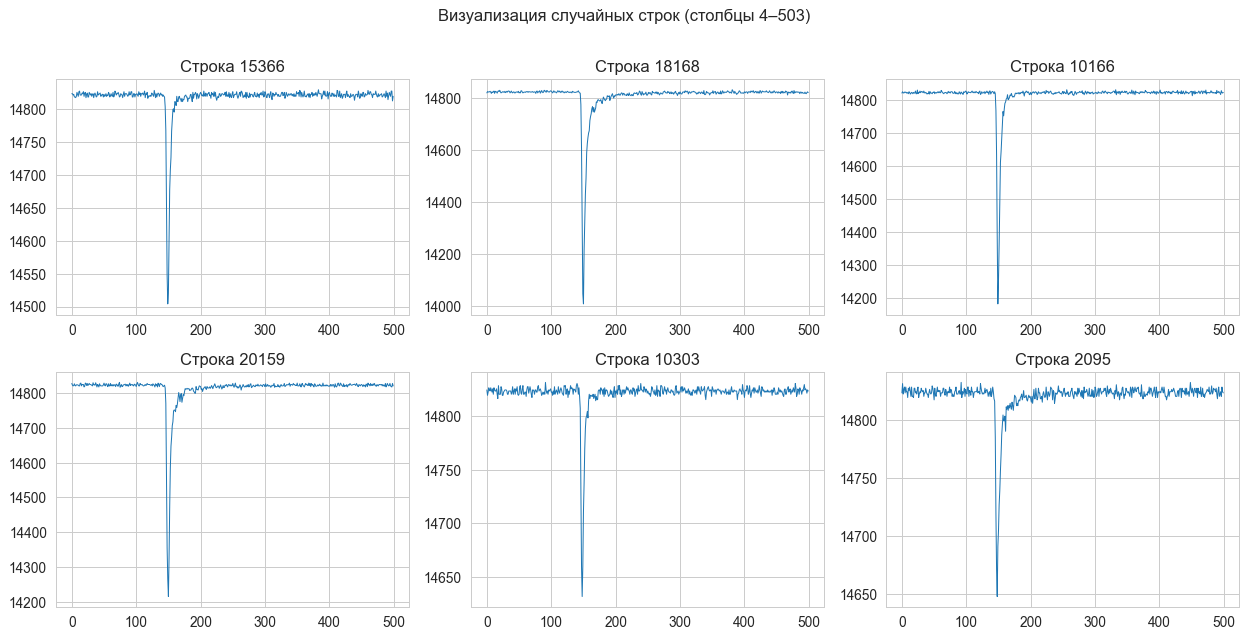

In [8]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(data), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, idx in zip(axes.flat, sample_idx):
    ax.plot(data.iloc[idx, 4:].values, lw=0.8)
    ax.set_title(f'Строка {idx}')
fig.suptitle('Визуализация случайных строк (столбцы 4–503)', y=1.01)
plt.tight_layout()
plt.show()

На всех шести графиках наблюдается одинаковая структура: значения держатся на постоянном уровне около 14 820, затем в определённый момент происходит резкий провал вниз, после чего значения плавно возвращаются к исходному уровню. Паттерн повторяется во всех строках, что говорит о том, что данные не являются случайным шумом, а описывают некоторые дискретные события.

При этом провалы различаются между собой: одни глубже, другие мельче, одни более узкие и острые, другие более пологие. Это может свидетельствовать о том, что записанные события имеют различную интенсивность или даже различную природу, что согласуется с постановкой задачи о кластеризации.

Также стоит отметить, что позиция провала у всех строк примерно одинакова (в районе 150-го отсчёта), что указывает на фиксированное окно записи.

Визуально полезная информация содержится именно в отклонении вниз от базового уровня. Чтобы подтвердить это количественно, на следующем шаге вычислим амплитуду отклонения в обе стороны от базовой линии и сравним результаты.

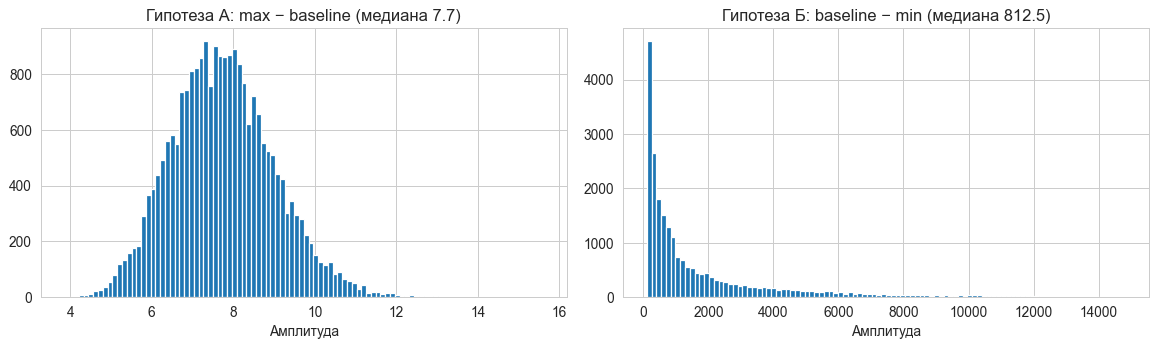

In [9]:
baselines = data.iloc[:, 4:54].mean(axis=1)

amp_1 = data.iloc[:, 4:].max(axis=1) - baselines
amp_2 = baselines - data.iloc[:, 4:].min(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(amp_1, bins=100)
ax1.set_title(f'Гипотеза А: max − baseline (медиана {amp_1.median():.1f})')
ax1.set_xlabel('Амплитуда')

ax2.hist(amp_2, bins=100)
ax2.set_title(f'Гипотеза Б: baseline − min (медиана {amp_2.median():.1f})')
ax2.set_xlabel('Амплитуда')

plt.tight_layout()
plt.show()

Гипотеза А даёт медиану 7.7, а всё распределение укладывается в диапазон 4–16. Это похоже на случайный шум, никакой полезной информации здесь нет.

Гипотеза Б даёт медиану 812.5 с разбросом от десятков до 14 000. Распределение имеет выраженную асимметрию, что говорит о наличии событий разной интенсивности.

Вывод: полезный сигнал это отклонение вниз от базовой линии. Для удобства дальнейшей работы инвертируем данные, чтобы импульсы были направлены вверх.

### 2. Предобработка: инверсия импульсов

Средняя базовая линия: 14823.0
Диапазон после инверсии: [-15.6, 14824.8]


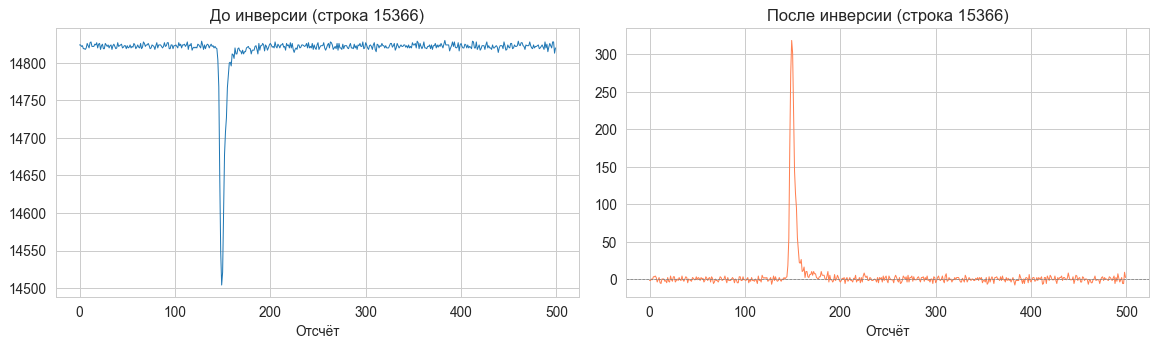

In [10]:
baselines = data.iloc[:, 4:54].mean(axis=1)
signals_inv = baselines.values[:, None] - data.iloc[:, 4:].values

print(f'Средняя базовая линия: {baselines.mean():.1f}')
print(f'Диапазон после инверсии: [{signals_inv.min():.1f}, {signals_inv.max():.1f}]')

idx = sample_idx[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(data.iloc[idx, 4:].values, lw=0.8)
ax1.set_title(f'До инверсии (строка {idx})')
ax1.set_xlabel('Отсчёт')

ax2.plot(signals_inv[idx], lw=0.8, color='coral')
ax2.axhline(0, color='gray', lw=0.6, ls='--')
ax2.set_title(f'После инверсии (строка {idx})')
ax2.set_xlabel('Отсчёт')

plt.tight_layout()
plt.show()

После инверсии импульс направлен вверх, а базовая линия совмещена с нулём. Теперь форма сигнала читается естественно: резкий подъём в момент регистрации события, затем постепенный спад. Именно в форме этого спада, как следует из описания задачи, содержатся различия между типами частиц. Далее будем работать с инвертированными данными.

In [11]:
amplitudes = signals_inv.max(axis=1)
peak_positions = signals_inv.argmax(axis=1)

stats_df = pd.DataFrame({
    'amplitude': amplitudes,
    'peak_position': peak_positions,
    'baseline': baselines,
    'noise_std': data.iloc[:, 4:54].std(axis=1),
})

stats_df.describe()

,amplitude,peak_position,baseline,noise_std
count,23479.000000,23479.000000,23479.000000,23479.000000
mean,1835.104716,149.628604,14822.966507,2.707879
std,2389.300501,2.489996,0.856405,0.267253
min,104.300000,145.000000,14818.920000,1.690429
25%,308.160000,149.000000,14822.380000,2.526916
50%,812.540000,150.000000,14822.960000,2.701776
75%,2315.050000,151.000000,14823.540000,2.883026
max,14824.840000,472.000000,14826.480000,3.791774


Амплитуды сильно различаются: от 104 до 14 825 при медиане 813. Большинство сигналов слабые, но попадаются и очень интенсивные.

Базовая линия и уровень шума стабильны по всей выборке, значит условия записи не менялись.

Отметим следующее: позиция пика у подавляющего большинства сигналов приходится на отсчёты 149–151, но есть сигнал с пиком на отсчёте 472. Стоит посмотреть на него отдельно, возможно это аномалия.

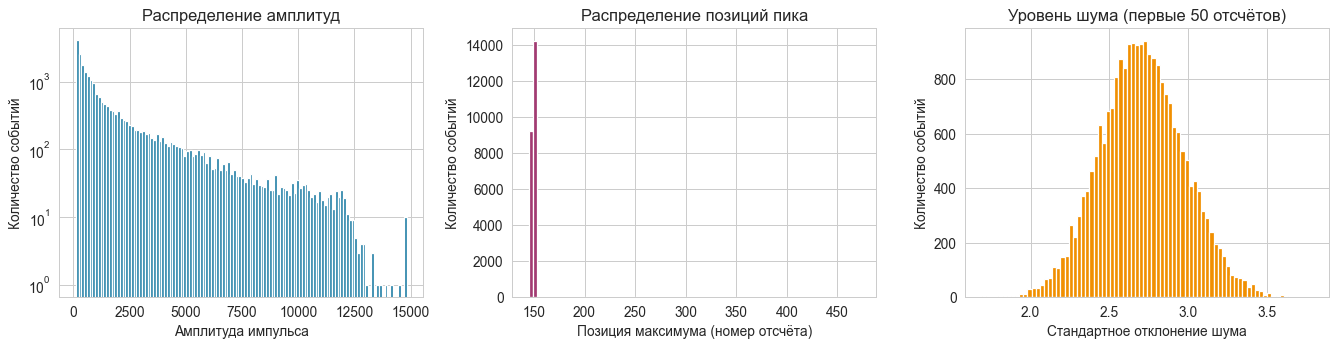

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(amplitudes, bins=120, color='#2E86AB', edgecolor='white')
axes[0].set_xlabel('Амплитуда импульса')
axes[0].set_ylabel('Количество событий')
axes[0].set_title('Распределение амплитуд')
axes[0].set_yscale('log')

axes[1].hist(peak_positions, bins=80, color='#A23B72', edgecolor='white')
axes[1].set_xlabel('Позиция максимума (номер отсчёта)')
axes[1].set_ylabel('Количество событий')
axes[1].set_title('Распределение позиций пика')

axes[2].hist(stats_df['noise_std'], bins=80, color='#F18F01', edgecolor='white')
axes[2].set_xlabel('Стандартное отклонение шума')
axes[2].set_ylabel('Количество событий')
axes[2].set_title('Уровень шума (первые 50 отсчётов)')

plt.tight_layout()
plt.show()


Гистограммы подтверждают то, что было видно из первых ячеек ноутбук (data.describe). Распределение амплитуд экспоненциально убывает: основная масса сигналов имеет амплитуду до 2500, более сильные события встречаются всё реже. Позиция пика практически у всех сигналов одинакова (около 150), единичный выброс на 472 подтверждается визуально. Уровень шума распределён нормально с центром около 2.7, что говорит об однородности условий записи.

В целом, завершаем EDA и попробуем построить модель.

### 3. Экспериметн 1: кластеризация 500-мерных векторов (снижение размерности + K-Means/DBSCAN)


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.iloc[:, 4:])
print(f'Форма: {X_scaled.shape}')

Форма: (23479, 500)


Масштабировали данные для корректного применения PCA и других методов снижения размерности.

Можем исследовать параметры для PCA вручную, но перед этим посмотрим на график кумулятивной объяснённой дисперсии.

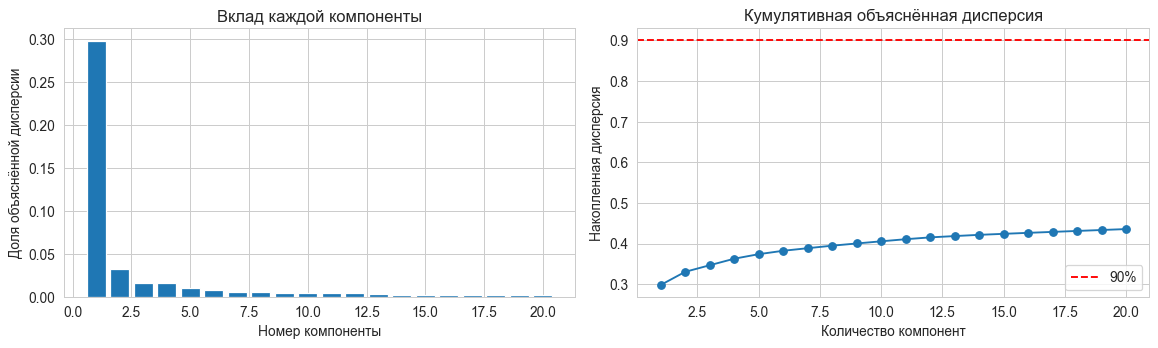

In [14]:
pca_full = PCA(n_components=20, random_state=42)
pca_full.fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(1, 21), pca_full.explained_variance_ratio_)
ax1.set_xlabel('Номер компоненты')
ax1.set_ylabel('Доля объяснённой дисперсии')
ax1.set_title('Вклад каждой компоненты')

ax2.plot(range(1, 21), np.cumsum(pca_full.explained_variance_ratio_), marker='o')
ax2.set_xlabel('Количество компонент')
ax2.set_ylabel('Накопленная дисперсия')
ax2.set_title('Кумулятивная объяснённая дисперсия')
ax2.axhline(0.9, color='red', ls='--', label='90%')
ax2.legend()

plt.tight_layout()
plt.show()

График свидетельствует о том, что PCA на этих данных будет работает неэффективно, т.к. каждая следующая компонента добавляет совсем немного к объяснённой дисперсии. Вариация не более 30-40% (даже при большом количестве компонент). Информация распределена по большому числу направлений и ни одно из них не доминирует.

Это может говорить о том, что различия между сигналами носят скорее нелинейный характер. При таком раскладе можно было бы перебирать число компонент вручную (5, 10, 50...), но с высокой вероятностью будем подбирать проекцию шума, а не полезного сигнала.

Имеет смысл сразу попробовать нелинейные методы (t-SNE и UMAP) и сравнить, дадут ли они более выраженную кластерную структуру.

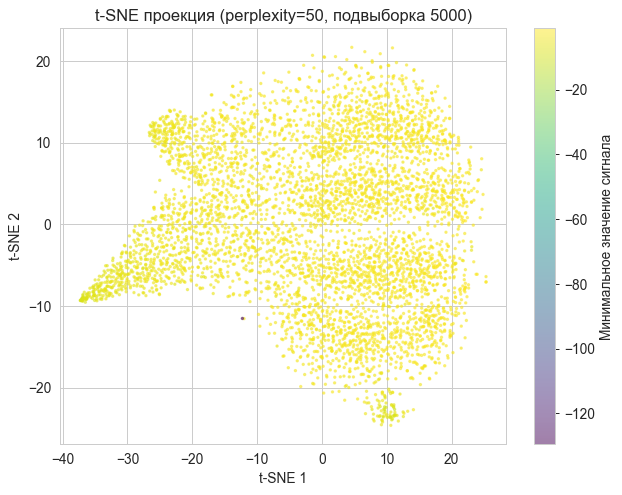

In [15]:
np.random.seed(42)
tsne_idx = np.random.choice(len(X_scaled), size=5000, replace=False)

tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled[tsne_idx])

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=X_scaled[tsne_idx].min(axis=1), cmap='viridis', s=3, alpha=0.5)
plt.colorbar(label='Минимальное значение сигнала')
plt.title('t-SNE проекция (perplexity=50, подвыборка 5000)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

Проекция t-SNE при perplexity=50 выявляет слабо выраженную кластерную структуру: визуально можно различить несколько обособленных групп точек, однако границы между ними размыты и нет чёткого градиента, который свидетельствовал бы об однозначном разделении сигналов.

Также обращает на себя внимание единичная точка с экстремально низким значением (фиолетовый цвет), существенно отстоящая от основной массы данных. Вероятно это выброс, который при кластеризации может быть отнесён к группе аномальных сигналов.

**Тут я попробовала еще вручную скорректировать параметр perpplexity, но изменения не дали улучшения. 


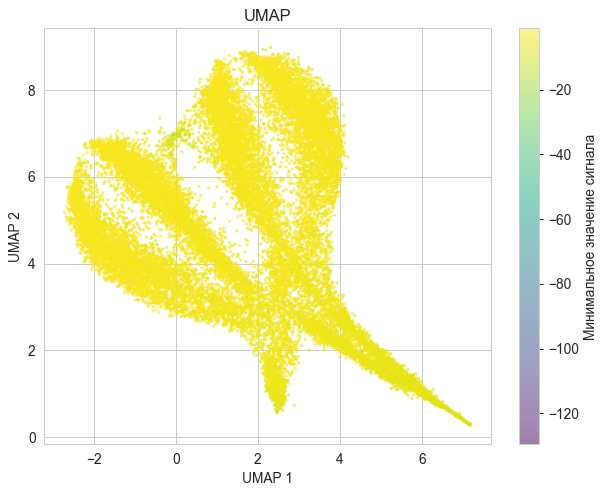

In [16]:
umap_model = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=X_scaled.min(axis=1), cmap='viridis', s=3, alpha=0.5)
plt.colorbar(label='Минимальное значение сигнала')
plt.title('UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

UMAP выявляет отчётливую структуру в данных: сигналы распределяются не однородным облаком, а формируют несколько расходящихся ветвей. Это свидетельствует о том, что среди сигналов существуют группы с различной формой, и является хорошим признаком для кластеризации. Попробуем построить модель именно на UMAP и визуализировать результаты. 

Размеры кластеров: [ 5875  1673 15931]
Силуэт: 0.1458
Calinski-Harabasz: 3886.0


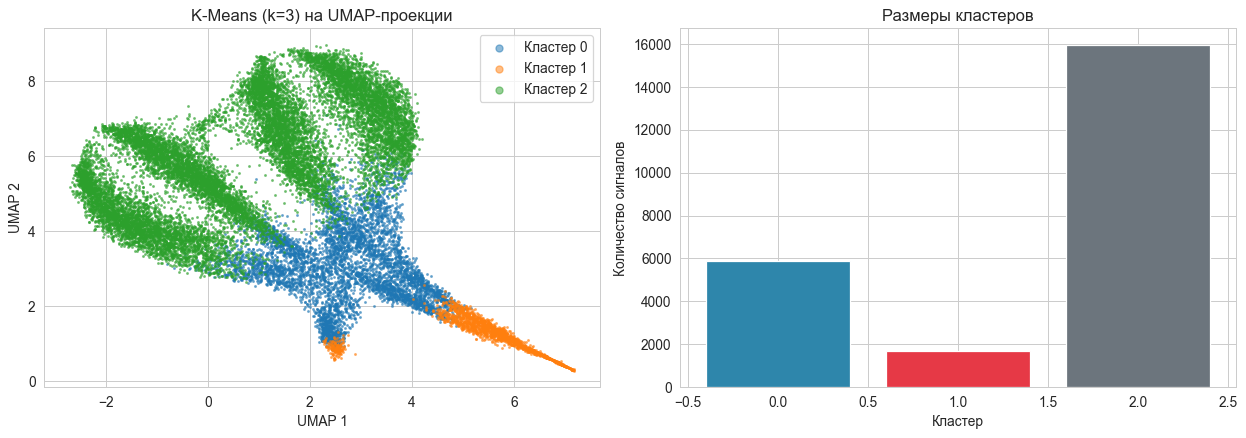

In [17]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)

print(f'Размеры кластеров: {np.bincount(labels_km)}')
print(f'Силуэт: {silhouette_score(X_scaled, labels_km):.4f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X_scaled, labels_km):.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for c in range(3):
    mask = labels_km == c
    ax1.scatter(X_umap[mask, 0], X_umap[mask, 1], s=2, alpha=0.5, label=f'Кластер {c}')
ax1.set_title('K-Means (k=3) на UMAP-проекции')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend(markerscale=4)

ax2.bar([0, 1, 2], np.bincount(labels_km), color=['#2E86AB', '#E63946', '#6C757D'])
ax2.set_xlabel('Кластер')
ax2.set_ylabel('Количество сигналов')
ax2.set_title('Размеры кластеров')

plt.tight_layout()
plt.show()

K-Means выделяет три кластера с выраженным дисбалансом: основная масса сигналов (15 931) попадает в кластер 2, в то время как кластер 1 содержит лишь 1 673 наблюдения и соответствует обособленной ветви на UMAP-проекции. Коэффициент силуэта 0.15 свидетельствует о значительном перекрытии кластеров. Все-таки границы между ними размыты.

In [18]:
submission = pd.DataFrame({
    'index': range(len(labels_km)),
    'cluster': labels_km
})
submission.to_csv('submission.csv', index=False)
print(f'Сохранено {len(submission)} строк в submission.csv')
print(submission['cluster'].value_counts().sort_index())

Сохранено 23479 строк в submission.csv
cluster
0     5875
1     1673
2    15931
Name: count, dtype: int64


Мы, конечно, в рамках исследования не ориентируемся на скор на каггле, но в любом случае получился он очень слабым. 
Продолжаем научные изыскания.

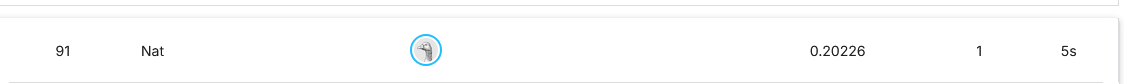

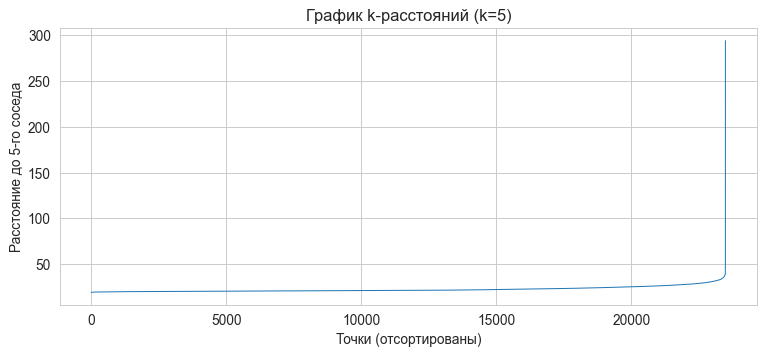

In [19]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist, lw=0.8)
plt.title('График k-расстояний (k=5)')
plt.xlabel('Точки (отсортированы)')
plt.ylabel('Расстояние до 5-го соседа')
plt.show()

Найдено кластеров: 1
Выбросов: 3537 (15.1%)


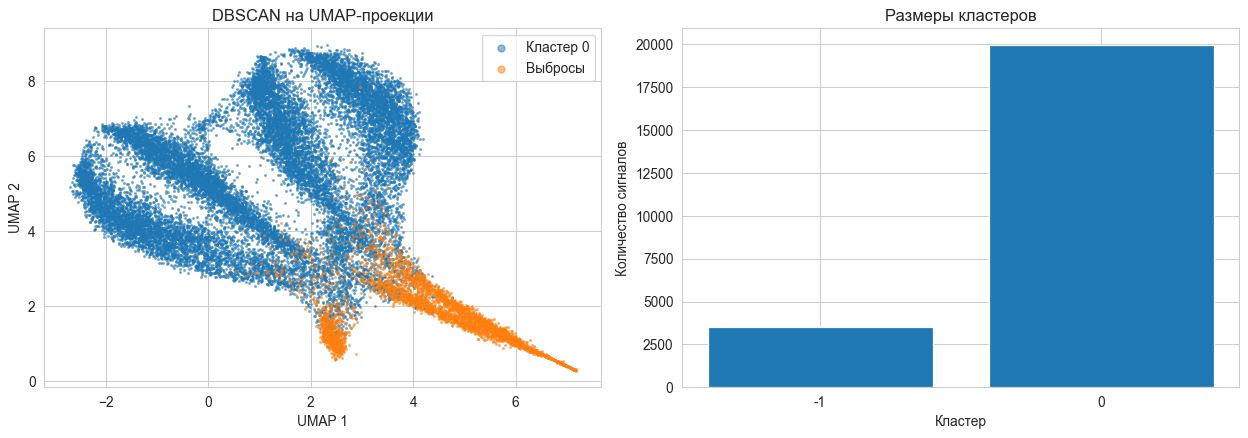

In [20]:
db = DBSCAN(eps=25, min_samples=5)
labels_db = db.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'Найдено кластеров: {n_clusters}')
print(f'Выбросов: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for c in set(labels_db):
    mask = labels_db == c
    label = f'Кластер {c}' if c != -1 else 'Выбросы'
    ax1.scatter(X_umap[mask, 0], X_umap[mask, 1], s=2, alpha=0.5, label=label)
ax1.set_title('DBSCAN на UMAP-проекции')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend(markerscale=4)

counts = pd.Series(labels_db).value_counts().sort_index()
ax2.bar(counts.index.astype(str), counts.values)
ax2.set_xlabel('Кластер')
ax2.set_ylabel('Количество сигналов')
ax2.set_title('Размеры кластеров')

plt.tight_layout()
plt.show()

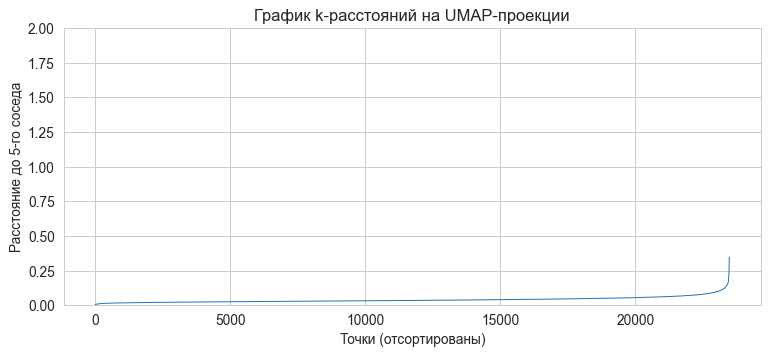

In [21]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_umap)
distances, _ = nn.kneighbors(X_umap)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist, lw=0.8)
plt.title('График k-расстояний на UMAP-проекции')
plt.xlabel('Точки (отсортированы)')
plt.ylabel('Расстояние до 5-го соседа')
plt.ylim(0, 2)
plt.show()

Найдено кластеров: 3
Выбросов: 105 (0.4%)
Силуэт: -0.2998


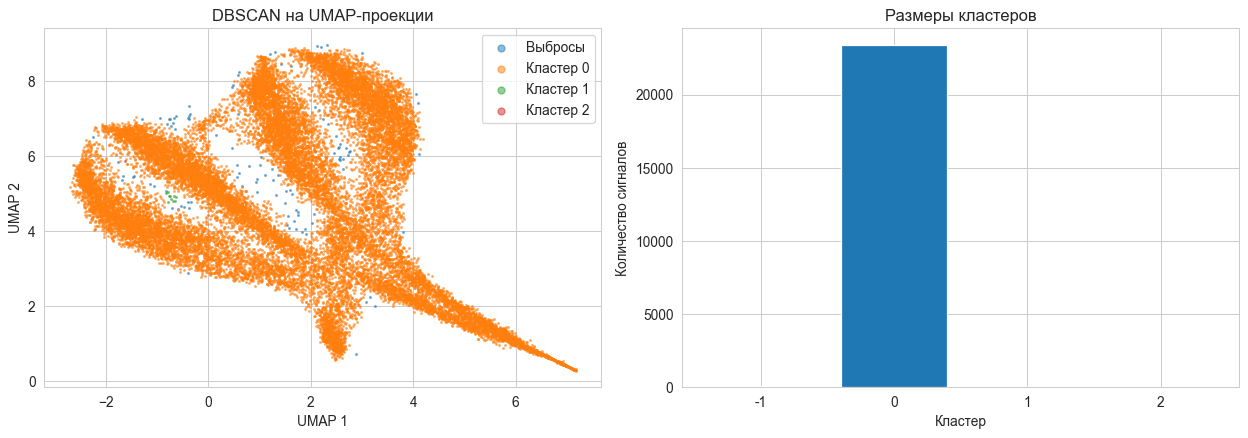

In [22]:
db = DBSCAN(eps=0.11, min_samples=5)
labels_db = db.fit_predict(X_umap)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'Найдено кластеров: {n_clusters}')
print(f'Выбросов: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)')
print(f'Силуэт: {silhouette_score(X_umap, labels_db):.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for c in sorted(set(labels_db)):
    mask = labels_db == c
    label = f'Кластер {c}' if c != -1 else 'Выбросы'
    ax1.scatter(X_umap[mask, 0], X_umap[mask, 1], s=2, alpha=0.5, label=label)
ax1.set_title('DBSCAN на UMAP-проекции')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend(markerscale=4)

counts = pd.Series(labels_db).value_counts().sort_index()
ax2.bar(counts.index.astype(str), counts.values)
ax2.set_xlabel('Кластер')
ax2.set_ylabel('Количество сигналов')
ax2.set_title('Размеры кластеров')

plt.tight_layout()
plt.show()

DBSCAN на UMAP при eps=0.11 (подобрали вручную) выделил 3 кластера и 105 выбросов, однако разделение оказалось крайне несбалансированным: подавляющее большинство сигналов попало в один кластер. Отрицательный коэффициент силуэта (−0.30) свидетельствует о том, что найденные кластеры не отражают реальную структуру данных. DBSCAN чувствителен к выбору eps, и в данном случае не удалось подобрать значение, дающее осмысленное разделение на три сопоставимые группы.

In [23]:
submission = pd.DataFrame({
    'index': range(len(labels_db)),
    'cluster': labels_db
})
submission.to_csv('submission.csv', index=False)
print(f'Сохранено {len(submission)} строк в submission.csv')
print(submission['cluster'].value_counts().sort_index())

Сохранено 23479 строк в submission.csv
cluster
-1      105
 0    23363
 1       10
 2        1
Name: count, dtype: int64


DBSCAN показал себя чуть-чуть лучше Kmeans на том же методе, но результаты все еще сомнительные. Попробуем feature engineering. 

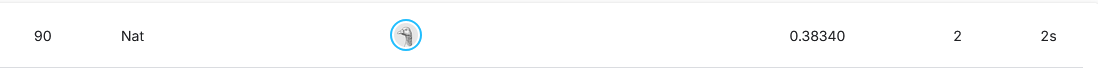

### 4. Эксперимент 2: feature engineering (извлечение и отбор мета-признаков)

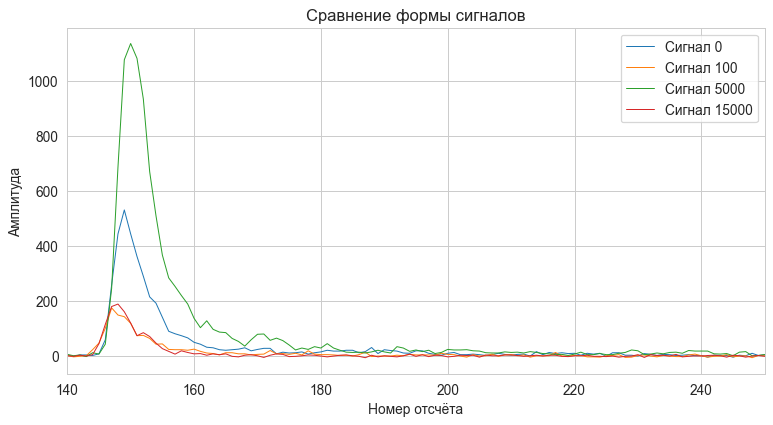

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
compare_idx = [0, 100, 5000, 15000]
for idx in compare_idx:
    ax.plot(signals_inv[idx], lw=0.8, label=f'Сигнал {idx}')
ax.set_xlabel('Номер отсчёта')
ax.set_ylabel('Амплитуда')
ax.set_title('Сравнение формы сигналов')
ax.legend()
ax.set_xlim(140, 250)
plt.show()

На графике видно, что сигналы отличаются по высоте, ширине и даже скорости падения амплитуды. 

Попробуем сформировать мета-признаки на основе этих наблюдений:
- высота пика и площадь под импульсом (для описания различий в масштабе)
- ширину сигнала и признак соотношения амплитуды к площади (для описания различий в форме)
- ассиметрию и остроту хвоста спада (для описания различий в форме спада амплитуды). 

Также добавим еще два признака для отлова выбросов и аномальных значений (уровень шума в зоне перед импульсом и положение пика).

Также, пользуясь подсказками Description и ресурсами интернета добавляем два признака, специфичных для этой задачи, tau (постоянная времени экспоненциального спада) и psd (Pulse Shape Discrimination — соотношение площадей разных участков импульса), поскольку из описания задачи следует, что ключевое различие между типами частиц именно скорость спада. 

Достаточно ли такого набора признаков или может быть он, наоборот, избыточен - попробуем проверить с помощью матрицы корреляции. 

In [25]:
def exp_decay(t, A, tau):
    return A * np.exp(-t / tau)


def extract_features(signal, baseline_std):

    amplitude = signal.max()
    peak_pos = int(signal.argmax())
    
    noise_threshold = 3 * baseline_std
    tail = signal[peak_pos:]
    above_noise = tail > noise_threshold
    end_idx = peak_pos + int(np.where(above_noise)[0].max()) if above_noise.any() else peak_pos
    
    signal_length = end_idx - peak_pos + 1
    tail = signal[peak_pos:end_idx + 1]
    area = float(tail.sum()) if signal_length > 0 else 0.0
    
    long_area = float(signal[peak_pos + 3:end_idx + 1].sum())
    short_area = float(signal[peak_pos + 3:peak_pos + 8].sum())
    psd = (long_area - short_area) / long_area if long_area > 1e-6 else np.nan
    
    below_60 = tail < 0.6 * amplitude
    fit_start = peak_pos + (int(np.where(below_60)[0].min()) if below_60.any() else 0)
    fit_end = end_idx + 1
    
    tau = np.nan
    if fit_end - fit_start >= 5 and amplitude > noise_threshold:
        t_fit = np.arange(fit_end - fit_start, dtype=float)
        y_fit = signal[fit_start:fit_end].astype(float)
        try:
            popt, _ = curve_fit(exp_decay, t_fit, y_fit,
                                p0=[y_fit[0], 5.0],
                                bounds=([1e-3, 0.1], [np.inf, 1000.0]),
                                maxfev=2000)
            tau = float(popt[1])
        except Exception:
            tau = np.nan
    
    sk = float(skew(tail)) if signal_length >= 3 else np.nan
    kt = float(kurtosis(tail)) if signal_length >= 3 else np.nan
    
    return {
        'amplitude':      float(amplitude),
        'area':           area,
        'signal_length':  float(signal_length),
        'peak_position':  float(peak_pos),
        'baseline_std':   float(baseline_std),
        'tau':            tau,
        'psd':            psd,
        'skewness':       sk,
        'kurtosis':       kt,
        'ratio_amp_area': amplitude / area if area > 1e-6 else np.nan,
    }


Функция extract_features берёт один сигнал, находит в нём пик, определяет границу затухания по порогу и на этом участке считает все десять признаков. Если фит экспоненты не сходится, возвращает NaN. Применяем ко всем 23 479 сигналам.

In [26]:
baselines_std = signals_inv[:, :50].std(axis=1)

records = []
for i in tqdm(range(len(signals_inv)), desc='Извлечение признаков'):
    records.append(extract_features(signals_inv[i], baselines_std[i]))

features_df = pd.DataFrame(records)
print(f'Размер: {features_df.shape}')
print(f'Пропуски:\n{features_df.isna().sum()}')

Извлечение признаков: 100%|██████████| 23479/23479 [01:11<00:00, 328.50it/s]

Размер: (23479, 10)
Пропуски:
amplitude         0
area              0
signal_length     0
peak_position     0
baseline_std      0
tau               2
psd               3
skewness          0
kurtosis          0
ratio_amp_area    0
dtype: int64


In [27]:
features_df = features_df.fillna(features_df.median())
features_df.describe().round(2)

,amplitude,area,signal_length,peak_position,baseline_std,tau,psd,skewness,kurtosis,ratio_amp_area
count,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00
mean,1835.10,10182.08,241.83,149.63,2.68,4.55,0.49,6.61,51.04,0.18
std,2389.30,12373.23,100.44,2.49,0.26,1.52,0.15,1.94,23.99,0.04
min,104.30,148.36,7.00,145.00,1.67,1.80,-5.85,-0.30,-1.68,0.08
25%,308.16,1888.25,176.00,149.00,2.50,3.23,0.38,5.70,34.82,0.14
50%,812.54,4917.20,276.00,150.00,2.67,4.21,0.53,7.20,56.24,0.17
75%,2315.05,13601.75,326.00,151.00,2.85,5.58,0.61,8.00,69.29,0.21
max,14824.84,96496.80,354.00,472.00,3.75,18.31,0.84,12.20,166.76,0.88


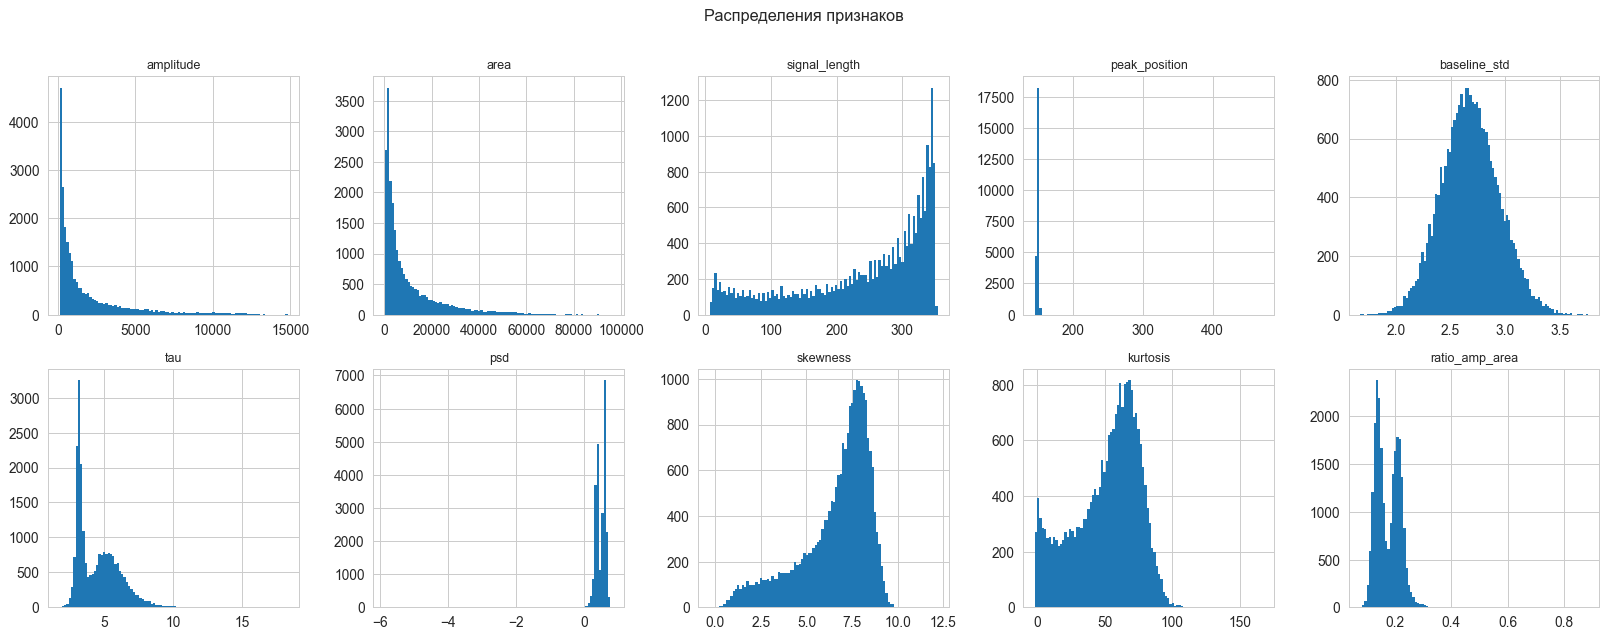

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, features_df.columns):
    ax.hist(features_df[col], bins=100, edgecolor='none')
    ax.set_title(col, fontsize=10)
plt.suptitle('Распределения признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

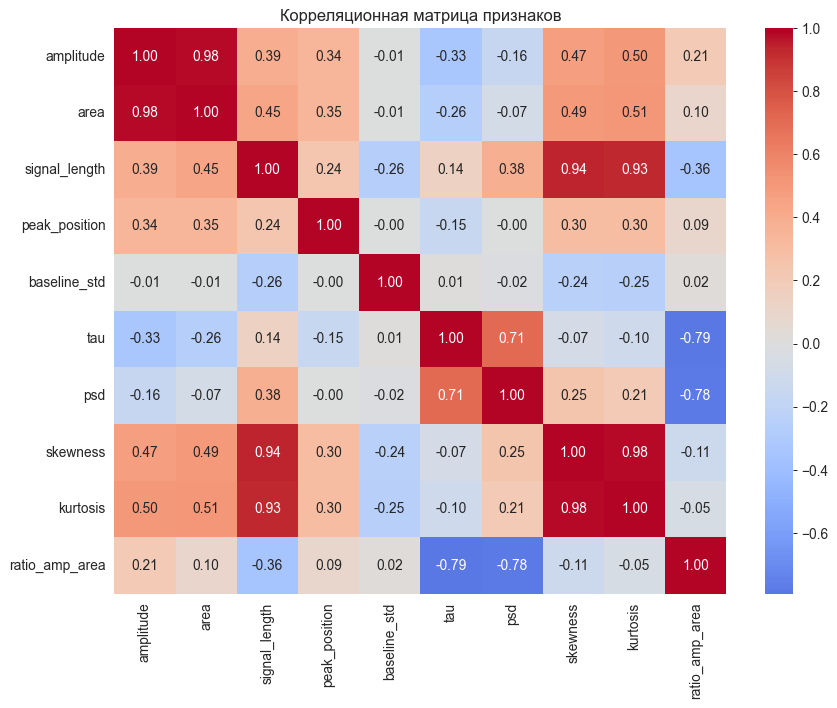

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(features_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

Из матрицы распределения и матрицы корреляции видно, что можно сократить и эти вновь созданные 10 признаков: 
- amplitude и area коррелируют на 0,98 - можем оставить один из них;
- skewness и kurtosis также коррелируют между собой, плюс еще и к ширине сигнала;
- baseline_std и peak_position практически не связаны с остальными признаками (они вряд ли помогут при кластеризации).

Попробуем оставить топ-5 признаков:
- amplitude
- signal_length (skewness и kurtosis выкидываем — дублируют на 0.93–0.94)
- tau
- psd
- ratio_amp_area


In [30]:
features_selected = features_df[['amplitude', 'signal_length', 'tau', 'psd', 'ratio_amp_area']]
print(features_selected.shape)

(23479, 5)


### 4.1. Снижение размерности на инжерных признаках: сравнение PCA/t-SNE/UMAP/MDS

In [31]:
features_work = features_selected.copy()
for col in ['amplitude', 'signal_length']:
    features_work[col] = np.log1p(features_work[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_work.values.astype(np.float32))
print(f'Итоговый набор: {X_scaled.shape}')

Итоговый набор: (23479, 5)


Перед запуском методов снижения размерности и кластеризации обработали пропуски в синтезированных признаках и логарифмировали amplitude, area, tau, signal_length для выравнивания правосторонней асимметрии. Признаки стандартизировали для корректной отработки методов снижения размерности. 

In [32]:
color = features_selected['psd'].values
color = np.clip(color, *np.nanpercentile(color, [1, 99]))

PCA объяснённая дисперсия: [0.548 0.302], сумма: 0.850


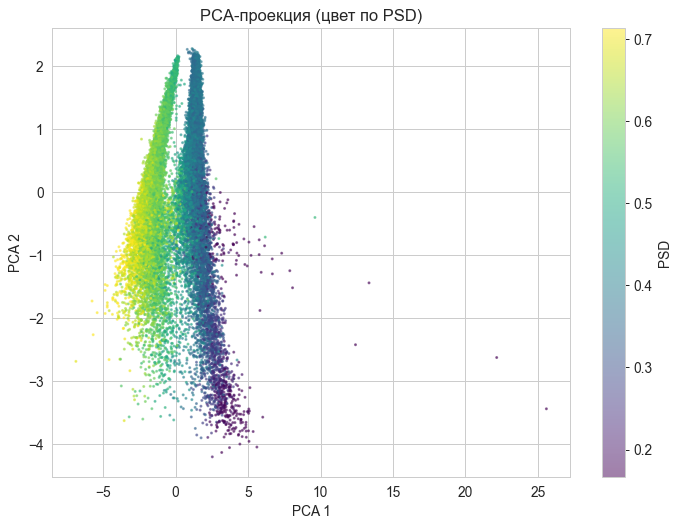

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA объяснённая дисперсия: {pca.explained_variance_ratio_.round(3)}, сумма: {pca.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(label='PSD')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA-проекция (цвет по PSD)')
plt.tight_layout()
plt.show()

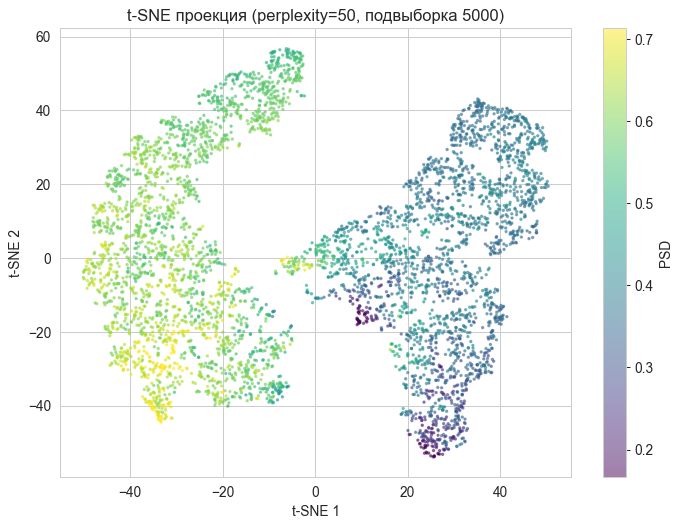

In [34]:
np.random.seed(42)
tsne_idx = np.random.choice(len(X_scaled), size=5000, replace=False)

tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled[tsne_idx])

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color[tsne_idx], cmap='viridis', s=3, alpha=0.5)
plt.colorbar(label='PSD')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE проекция (perplexity=50, подвыборка 5000)')
plt.tight_layout()
plt.show()

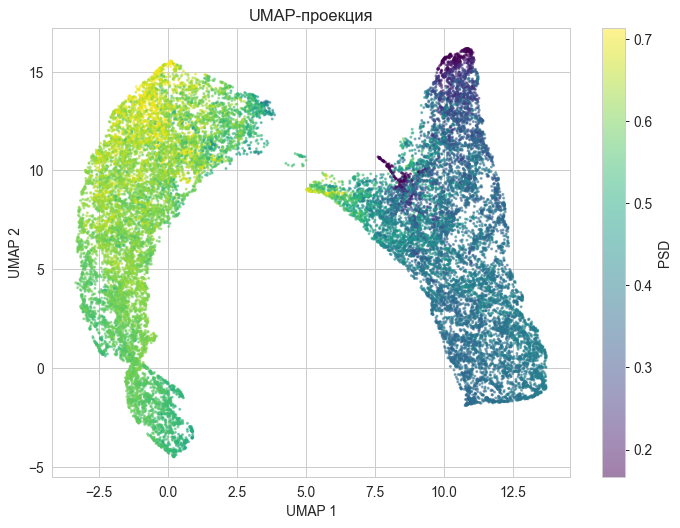

In [35]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=color, cmap='viridis', s=2, alpha=0.5)
plt.colorbar(label='PSD')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP-проекция')
plt.tight_layout()
plt.show()

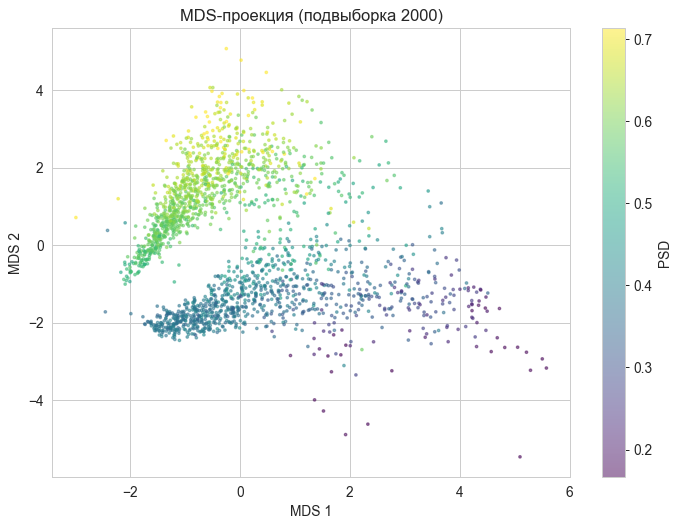

In [36]:
np.random.seed(42)
mds_idx = np.random.choice(len(X_scaled), size=2000, replace=False)

mds = MDS(n_components=2, random_state=42, n_jobs=-1)
X_mds = mds.fit_transform(X_scaled[mds_idx])

plt.figure(figsize=(8, 6))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=color[mds_idx], cmap='viridis', s=4, alpha=0.5)
plt.colorbar(label='PSD')
plt.xlabel('MDS 1')
plt.ylabel('MDS 2')
plt.title('MDS-проекция (подвыборка 2000)')
plt.tight_layout()
plt.show()

Все четыре метода в основном демонстрируют разделение данных на две основные группы, граница между которыми практически совпадает с градиентом PSD. Это говорит о том, что PSD — главный параметр, по которому различаются сигналы. Поскольку одну и ту же структуру дают различные методы (линейные и нелинейные) можно сказать, что есть существенное разделение в данных, а не особенность какого-то из алгоритмов. 

#### Сравнительный анализ методов

PCA

Метод показывает общую структуру: две группы сходятся вверху и расходятся веером, а PSD плавно меняется вдоль первой главной компоненты. Чётко разделить кластеры PCA не может (линейный), но зато хорошо ловит выбросы^ несколько точек со значениями PCA 1 до 25, которые могут быть аномальными сигналами.

t-SNE (perplexity = 50, подвыборка 5000)

Метод формирует два явно обособленных кластера: левый соответствует высоким значениям PSD, правый c низким и средним. В нижней части правого кластера видна компактная область с PSD около 0.2, которая может быть отдельным классом сигналов.

UMAP 

Обеспечивает наиболее выраженное разделение структуры. Помимо двух основных кластеров, в правой верхней части проекции чётко обособляется область сигналов с минимальным PSD, являющаяся наиболее вероятным кандидатом на третий (аномальный) класс. С учётом качества разделения и сохранения как локальной, так и глобальной структуры, UMAP-проекция выбрана в качестве входного пространства для последующей кластеризации методами K-Means и DBSCAN.

MDS (подвыборка 2000)

Подтверждает, что групп две, но разделение более размытое: кластеры местами перетекают друг в друга, а область низкого PSD вытягивается в хвост. Ничего нового по сравнению с UMAP и t-SNE метод не дает, при этом он самый тяжелый по вычислениям, поэтому для всей выборки плохо подходит.

### 4.2. Кластеризация по признакам: K-Means/DBSCAN/GMM, подбор гиперпараметров, оценка метрик

In [49]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_scaled.shape[0], size=5000, replace=False)

def quality(labels, name):
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    n_noise = int((labels == -1).sum())
    if n_clusters < 2:
        print(f"{name}: кластеров < 2")
        return
    s_idx = sample_idx[mask[sample_idx]]
    sil = silhouette_score(X_scaled[s_idx], labels[s_idx])
    db = davies_bouldin_score(X_scaled[mask], labels[mask])
    print(f"{name}: кластеров={n_clusters}, шум={n_noise}, "
          f"silhouette={sil:.3f}, davies-bouldin={db:.3f}")

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
quality(labels_kmeans, "K-Means")

dbscan = DBSCAN(eps=0.8, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_scaled)
quality(labels_dbscan, "DBSCAN")

gmm = GaussianMixture(n_components=3, covariance_type="full",
                      n_init=5, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
quality(labels_gmm, "GMM")

K-Means: кластеров=3, шум=0, silhouette=0.422, davies-bouldin=0.911
DBSCAN: кластеров < 2
GMM: кластеров=3, шум=0, silhouette=0.299, davies-bouldin=1.407


In [ ]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_scaled.shape[0], size=5000, replace=False)

def score(labels):
    mask = labels != -1
    n_cl = len(set(labels[mask]))
    if n_cl < 2:
        return n_cl, np.nan, np.nan, np.nan
    s = sample_idx[mask[sample_idx]]
    sil = silhouette_score(X_scaled[s], labels[s])
    db = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
    return n_cl, sil, db, ch

In [39]:
print("=== K-Means (k=3) ===")
rows = []
for init in ['k-means++', 'random']:
    for n_init in [10, 25, 50]:
        km = KMeans(n_clusters=3, init=init, n_init=n_init,
                    max_iter=500, random_state=42)
        lab = km.fit_predict(X_scaled)
        _, sil, db, ch = score(lab)
        rows.append((init, n_init, sil, db, ch, km.inertia_))
df_km = pd.DataFrame(rows, columns=['init', 'n_init', 'silhouette', 'davies_bouldin', 'calinski', 'inertia'])
print(df_km.sort_values('silhouette', ascending=False).to_string(index=False))

=== K-Means (k=3) ===
     init  n_init  silhouette  davies_bouldin     calinski      inertia
k-means++      25    0.422618        0.908375 17106.671459 47772.656250
   random      50    0.422489        0.908869 17106.760885 47772.421875
   random      25    0.422489        0.908869 17106.760885 47772.425781
   random      10    0.422084        0.910176 17106.715593 47772.519531
k-means++      50    0.422024        0.910361 17106.705419 47772.519531
k-means++      10    0.421666        0.911114 17106.612449 47772.742188


In [40]:
print("\n=== GMM (n_components=3) ===")
rows = []
for cov in ['full', 'tied', 'diag', 'spherical']:
    for n_init in [5, 10]:
        gmm = GaussianMixture(n_components=3, covariance_type=cov,
                              n_init=n_init, max_iter=300, random_state=42)
        lab = gmm.fit_predict(X_scaled)
        _, sil, db, ch = score(lab)
        rows.append((cov, n_init, sil, db, ch, gmm.bic(X_scaled)))
df_gmm = pd.DataFrame(rows, columns=['cov_type', 'n_init', 'silhouette', 'davies_bouldin', 'calinski', 'bic'])
print(df_gmm.sort_values('silhouette', ascending=False).to_string(index=False))


=== GMM (n_components=3) ===
 cov_type  n_init  silhouette  davies_bouldin     calinski           bic
     tied      10    0.426075        0.879201 15672.227210 244807.126559
     tied       5    0.426075        0.879201 15672.227210 244807.126559
spherical       5    0.396917        1.020502 15294.237472 262239.004963
spherical      10    0.396917        1.020502 15294.237472 262239.004963
     diag      10    0.393248        1.059946 14884.437562 215736.991745
     diag       5    0.393248        1.059946 14884.437562 215736.991745
     full       5    0.298839        1.407421  8424.238007 174864.428625
     full      10    0.298839        1.407421  8424.238007 174864.383842


In [ ]:
print("\n=== DBSCAN (ищем ~3 кластера) ===")
rows = []
for eps in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]:
    for min_s in [10, 20, 30, 50]:
        db_m = DBSCAN(eps=eps, min_samples=min_s)
        lab = db_m.fit_predict(X_scaled)
        n_cl, sil, dbi, ch = score(lab)
        n_noise = int((lab == -1).sum())
        rows.append((eps, min_s, n_cl, n_noise, sil, dbi))
df_db = pd.DataFrame(rows, columns=['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette', 'davies_bouldin'])
print(df_db.sort_values('silhouette', ascending=False).to_string(index=False))
print("\nВарианты с 2 кластерами (+ шум = 3-й класс):")
print(df_db[df_db['n_clusters'] == 2].sort_values('silhouette', ascending=False).to_string(index=False))


=== DBSCAN (ищем ~3 кластера) ===
 eps  min_samples  n_clusters  n_noise  silhouette  davies_bouldin
 0.3           50           2    11125    0.594251        0.595082
 0.9           10           2       53    0.484769        0.531094
 0.5           50           2     2958    0.476824        0.870968
 0.3           30           3     9634    0.446763        0.668658
 0.3           20           3     8495    0.371015        0.662151
 0.5           10           3      684    0.185690        0.608627
 0.3           10          23     6029    0.059201        0.945814
 0.5           20           1     1271         NaN             NaN
 0.5           30           1     1880         NaN             NaN
 0.7           10           1      148         NaN             NaN
 0.7           20           1      218         NaN             NaN
 0.7           30           1      298         NaN             NaN
 0.7           50           1      454         NaN             NaN
 0.9           20          

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=25,
                max_iter=500, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=3, covariance_type='tied',
                      n_init=10, max_iter=300, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=50)
labels_dbscan = dbscan.fit_predict(X_scaled)

import pandas as pd
for name, lab in [("K-Means", labels_kmeans), ("GMM", labels_gmm), ("DBSCAN", labels_dbscan)]:
    print(f"{name}: {pd.Series(lab).value_counts().sort_index().to_dict()}")

K-Means: {0: 9065, 1: 10976, 2: 3438}
GMM: {0: 2370, 1: 9241, 2: 11868}
DBSCAN: {-1: 2958, 0: 10900, 1: 9621}


In [ ]:
import pandas as pd
import numpy as np

def relabel_by_order(labels):
    seen, out, nxt = {}, np.empty(len(labels), dtype=int), 0
    for i, l in enumerate(labels):
        if l not in seen:
            seen[l] = nxt; nxt += 1
        out[i] = seen[l]
    return out

def make_submission(labels, filename):
    clusters = relabel_by_order(labels)
    sub = pd.DataFrame({
        "index": np.arange(len(clusters)),
        "cluster": clusters,
    })
    sub.to_csv(filename, index=False)
    print(f"{filename}: {len(sub)} строк, "
          f"распределение={pd.Series(clusters).value_counts().sort_index().to_dict()}")
    return sub

sub_kmeans = make_submission(labels_kmeans, "submission_kmeans.csv")
sub_gmm    = make_submission(labels_gmm,    "submission_gmm.csv")
sub_dbscan = make_submission(labels_dbscan, "submission_dbscan.csv")

submission_kmeans.csv: 23479 строк, распределение={0: 10976, 1: 9065, 2: 3438}
submission_gmm.csv: 23479 строк, распределение={0: 11868, 1: 9241, 2: 2370}
submission_dbscan.csv: 23479 строк, распределение={0: 10900, 1: 9621, 2: 2958}


На этом этапе мы попробовали кластеризацию на инженерных признаках и их UMAP-проекции. Построили 3 модели: K-means, DBSCAN и GMM. Для этих моделей подобрали гиперпараметры. 
Забегая вперед скажу, что на инженерных признаках кластеризация оказалась существенно лучше, однако есть еще возможности для улучшения и осталась для проверки еще одна идея.


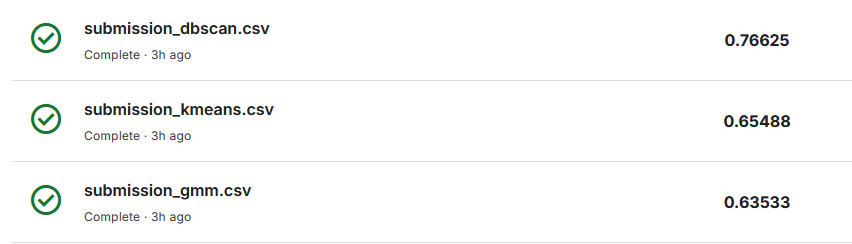

Идея: сначала выявить «некластеризуемые» аномалии и вынести их в отдельный класс, затем применить KMeans, разделив данные на 2 класса, получив итого 3 класса (гамма, нейтрон и аномалии).
Проверяем два признаковых пространства, полученных ранее: исходный масштабированный вектор (`X_scaled`) и двумерную UMAP-проекцию (`X_umap`).

Дополнительным экспериментом попробуем двухэтапный метод кластеризации на всем признаковом пространстве. 

### 5. Эксперимент 3: двухэтапная кластеризация на инженерных признаках

In [44]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.126, random_state=42, n_jobs=-1)
is_anom_iso = iso.fit_predict(X_scaled) == -1  # True = аномалия
print(f'IsolationForest: аномалий {is_anom_iso.sum()} ({is_anom_iso.mean()*100:.1f}%)')

db_stage1 = DBSCAN(eps=0.5, min_samples=50)
db1_labels = db_stage1.fit_predict(X_scaled)
is_anom_dbscan = db1_labels == -1
print(f'DBSCAN:           аномалий {is_anom_dbscan.sum()} ({is_anom_dbscan.mean()*100:.1f}%)')

results_feat = {}
for name, mask in [('iso', is_anom_iso), ('dbscan', is_anom_dbscan)]:
    X_clean = X_scaled[~mask]
    km2 = KMeans(n_clusters=2, n_init=25, random_state=42)
    clean_labels = km2.fit_predict(X_clean)
    sil = silhouette_score(X_clean, clean_labels)
    print(f'KMeans этап-2 [{name}]: silhouette={sil:.4f} (на {len(X_clean)} чистых точках)')
    results_feat[name] = (mask, clean_labels)

for name, (mask, clean_labels) in results_feat.items():
    full_labels = np.full(len(X_scaled), -1, dtype=int)
    full_labels[~mask] = clean_labels
    make_submission(full_labels, f'submission_twostage_feat_{name}.csv')


IsolationForest: аномалий 2959 (12.6%)
DBSCAN:           аномалий 2958 (12.6%)
KMeans этап-2 [iso]: silhouette=0.4750 (на 20520 чистых точках)
KMeans этап-2 [dbscan]: silhouette=0.4799 (на 20521 чистых точках)
submission_twostage_feat_iso.csv: 23479 строк, распределение={0: 10700, 1: 9820, 2: 2959}
submission_twostage_feat_dbscan.csv: 23479 строк, распределение={0: 10760, 1: 9761, 2: 2958}


В этом эксперименте мы попробовали двухэтапную кластеризацию на пространстве из 5 инженерных признаков: 
на первом этапе отделяли аномалии двумя методами (IsolationForest и DBSCAN), на втором делили 
оставшиеся чистые точки на 2 кластера с помощью KMeans.

Оба метода поиска аномалий отсекли примерно по 12.6% сигналов в третий класс 
(2959 и 2958 точек), доли почти совпали. Распределения по классам у обоих вариантов тоже вышли 
почти одинаковыми ({0: 10700, 1: 9820, 2: 2959}). silhouette на этапе 2 составил 0.475 (iso) 
и 0.480 (dbscan).

Метрика Silhouette по данному этапу (0.48) оказалась не выше, чем у одностадийного DBSCAN 
на тех же признаках (0.477), т.е. усложнение схемы до двух стадий не дало никакого прироста. 

Вероятно, проблема в том, что 5 наших инженерных мер дают слишком размытые границы между гаммой и нейтронами, а предварительный 
отсев аномалий это не исправляет. Выбор метода поиска аномалий тоже почти не влияет на результат. 


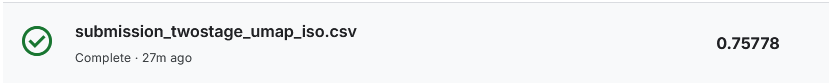

### 6. Эксперимент 4: двухэтапная кластеризация на UMAP-проекции инженерных признаков

In [45]:
iso_u = IsolationForest(contamination=0.126, random_state=42, n_jobs=-1)
is_anom_iso_u = iso_u.fit_predict(X_umap) == -1
print(f'IsolationForest (UMAP): аномалий {is_anom_iso_u.sum()} ({is_anom_iso_u.mean()*100:.1f}%)')

db_stage1_u = DBSCAN(eps=0.35, min_samples=50)
db1_labels_u = db_stage1_u.fit_predict(X_umap)
is_anom_dbscan_u = db1_labels_u == -1
print(f'DBSCAN (UMAP):          аномалий {is_anom_dbscan_u.sum()} ({is_anom_dbscan_u.mean()*100:.1f}%)')

results_umap = {}
for name, mask in [('iso', is_anom_iso_u), ('dbscan', is_anom_dbscan_u)]:
    X_clean_u = X_umap[~mask]
    km2_u = KMeans(n_clusters=2, n_init=25, random_state=42)
    clean_labels_u = km2_u.fit_predict(X_clean_u)
    sil_u = silhouette_score(X_clean_u, clean_labels_u)
    print(f'KMeans этап-2 [{name}]: silhouette={sil_u:.4f} (на {len(X_clean_u)} чистых точках)')
    results_umap[name] = (mask, clean_labels_u)

for name, (mask, clean_labels_u) in results_umap.items():
    full_labels_u = np.full(len(X_umap), -1, dtype=int)
    full_labels_u[~mask] = clean_labels_u
    make_submission(full_labels_u, f'submission_twostage_umap_{name}.csv')


IsolationForest (UMAP): аномалий 2959 (12.6%)
DBSCAN (UMAP):          аномалий 346 (1.5%)
KMeans этап-2 [iso]: silhouette=0.5642 (на 20520 чистых точках)
KMeans этап-2 [dbscan]: silhouette=0.5248 (на 23133 чистых точках)
submission_twostage_umap_iso.csv: 23479 строк, распределение={0: 10392, 1: 10128, 2: 2959}
submission_twostage_umap_dbscan.csv: 23479 строк, распределение={0: 11776, 1: 11357, 2: 346}


Здесь также попробовали применить двухэтапную схему кластеризации на тех же 5 инженерных признаках, полученных ранее, но в пространстве 2D UMAP-проекции: на первом этапе также отделяли аномалии (IsolationForest и DBSCAN), а на втором также делили оставшиеся чистые точки на 2 кластера с помощью KMeans.

Методы поиска аномалий разошлись сильно: IsolationForest отсёк 2959 точек (12.6%), 
а DBSCAN всего 346 (1.5%). silhouette этапа 2 составил 0.564 (iso) и 0.525 (dbscan). 
Распределения: у iso {0: 10392, 1: 10128, 2: 2959}, у dbscan {0: 11776, 1: 11357, 2: 346}. 

Этот эксперимент дал хорошее улучшение метрик и скор на каггле подрос. 

Почему это сработало: переход в пространство UMAP заметно улучшил разделение двух типов сигналов 
по сравнению с прямой работой на 5 признаках (silhouette -> 0.56). Лучший результат на 
Kaggle показал вариант с DBSCAN, где в третий класс попало всего 346 точек, что говорит о том, 
что доля аномальных сигналов в данных мала, и сабмиты с большим третьим классом 
(12.6%) её переоценивали. Основную работу здесь делает чёткое разделение двух типов на UMAP, 
а отсев аномалий лишь немного уточняет результат. 

Здесь в том числе опираемся на скор на Kagglе, поскольку в разных пространствах 
напрямую не сравним. 

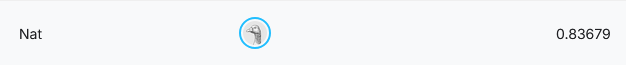

### 7. Эксперимент 5: двухэтапная кластеризация на всех сырых признаках (сравнение)

Предыдущие эксперименты использовали 5 инженерных признаков (`X_scaled`) и их UMAP-проекцию (`X_umap`); здесь мы проверяем, не потеряли ли информацию при feature engineering — повторяем тот же двухстадийный алгоритм прямо на полном сыром сигнальном векторе (~500 измерений).
Тестируем два пространства: сырые масштабированные признаки (`X_raw_scaled`) и их UMAP-проекцию (`X_raw_umap`).

In [46]:
X_raw_scaled = StandardScaler().fit_transform(data.iloc[:, 4:])
print(f'X_raw_scaled: {X_raw_scaled.shape}')

iso_raw = IsolationForest(contamination=0.126, random_state=42, n_jobs=-1)
is_anom_raw_iso = iso_raw.fit_predict(X_raw_scaled) == -1
print(f'IsolationForest: аномалий {is_anom_raw_iso.sum()} ({is_anom_raw_iso.mean()*100:.1f}%)')

db_raw = DBSCAN(eps=25, min_samples=50)
is_anom_raw_dbscan = db_raw.fit_predict(X_raw_scaled) == -1
print(f'DBSCAN:           аномалий {is_anom_raw_dbscan.sum()} ({is_anom_raw_dbscan.mean()*100:.1f}%)')

_rng_raw = np.random.default_rng(42)
results_raw = {}
for name, mask in [('iso', is_anom_raw_iso), ('dbscan', is_anom_raw_dbscan)]:
    X_clean_raw = X_raw_scaled[~mask]
    km_raw = KMeans(n_clusters=2, n_init=25, random_state=42)
    clean_raw_labels = km_raw.fit_predict(X_clean_raw)
    _sil_idx = _rng_raw.choice(len(X_clean_raw), size=min(5000, len(X_clean_raw)), replace=False)
    sil_raw = silhouette_score(X_clean_raw[_sil_idx], clean_raw_labels[_sil_idx])
    print(f'KMeans этап-2 [{name}]: silhouette={sil_raw:.4f} (на {len(X_clean_raw)} чистых, подвыборка 5000)')
    results_raw[name] = (mask, clean_raw_labels)

for name, (mask, clean_raw_labels) in results_raw.items():
    full_raw_labels = np.full(len(X_raw_scaled), -1, dtype=int)
    full_raw_labels[~mask] = clean_raw_labels
    make_submission(full_raw_labels, f'submission_twostage_raw_{name}.csv')


X_raw_scaled: (23479, 500)
IsolationForest: аномалий 2959 (12.6%)
DBSCAN:           аномалий 3672 (15.6%)
KMeans этап-2 [iso]: silhouette=0.1135 (на 20520 чистых, подвыборка 5000)
KMeans этап-2 [dbscan]: silhouette=0.0918 (на 19807 чистых, подвыборка 5000)
submission_twostage_raw_iso.csv: 23479 строк, распределение={0: 5974, 1: 14546, 2: 2959}
submission_twostage_raw_dbscan.csv: 23479 строк, распределение={0: 6205, 1: 13602, 2: 3672}


В этом эксперименте попробовали также двухэтапную кластеризацию, но уже на всем признаковом пространстве сырых данных до обработки. 
silhouette совсем низкий: 0.11 (iso) и 0.09 (dbscan). В 500-мерном пространстве кластеры не разделяются, т.к. слишком много шума и пустых измерений.

#### Двухэтапная кластеризация на всем признаковом пространстве (до feature engineering) на проекции UMAP

In [47]:
X_raw_umap = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42).fit_transform(X_raw_scaled)
print(f'X_raw_umap: {X_raw_umap.shape}')

iso_rawu = IsolationForest(contamination=0.126, random_state=42, n_jobs=-1)
is_anom_rawu_iso = iso_rawu.fit_predict(X_raw_umap) == -1
print(f'IsolationForest (UMAP raw): аномалий {is_anom_rawu_iso.sum()} ({is_anom_rawu_iso.mean()*100:.1f}%)')

db_rawu = DBSCAN(eps=0.35, min_samples=50)
is_anom_rawu_dbscan = db_rawu.fit_predict(X_raw_umap) == -1
print(f'DBSCAN (UMAP raw):          аномалий {is_anom_rawu_dbscan.sum()} ({is_anom_rawu_dbscan.mean()*100:.1f}%)')

results_rawu = {}
for name, mask in [('iso', is_anom_rawu_iso), ('dbscan', is_anom_rawu_dbscan)]:
    X_clean_rawu = X_raw_umap[~mask]
    km_rawu = KMeans(n_clusters=2, n_init=25, random_state=42)
    clean_rawu_labels = km_rawu.fit_predict(X_clean_rawu)
    sil_rawu = silhouette_score(X_clean_rawu, clean_rawu_labels)
    print(f'KMeans этап-2 [{name}]: silhouette={sil_rawu:.4f} (на {len(X_clean_rawu)} чистых точках)')
    results_rawu[name] = (mask, clean_rawu_labels)

for name, (mask, clean_rawu_labels) in results_rawu.items():
    full_rawu_labels = np.full(len(X_raw_umap), -1, dtype=int)
    full_rawu_labels[~mask] = clean_rawu_labels
    make_submission(full_rawu_labels, f'submission_twostage_rawumap_{name}.csv')


X_raw_umap: (23479, 2)
IsolationForest (UMAP raw): аномалий 2959 (12.6%)
DBSCAN (UMAP raw):          аномалий 1 (0.0%)
KMeans этап-2 [iso]: silhouette=0.3841 (на 20520 чистых точках)
KMeans этап-2 [dbscan]: silhouette=0.4275 (на 23478 чистых точках)
submission_twostage_rawumap_iso.csv: 23479 строк, распределение={0: 12260, 1: 8260, 2: 2959}
submission_twostage_rawumap_dbscan.csv: 23479 строк, распределение={0: 16679, 1: 6799, 2: 1}


В этом эксперименте попробовали также двухэтапную кластеризацию на всем признаковом пространстве сырых данных до обработки на проекции UMAP. 
Чуть лучше: silhouette 0.38 (iso) и 0.43 (dbscan), но DBSCAN нашёл всего 1 аномалию (eps не подходит под масштаб), так что вариант также несостоятельный.

### 8. Итоговый пайплайн и выводы: 

Финальное решение строится на двух ключевых идеях: **feature engineering** (из всего признакового пространства синтезируем осмысленные мета-признаки) и **двухэтапная кластеризация** (сначала отделяем аномалии в отдельный кластер, затем делим оставшиеся сигналы на 2 типа).

#### Шаг 1 - препроцессинг и feature engineering

Исходные данные составляли 23 479 сигналов, каждый описан 500 временными отсчётами. Работа с сырыми векторами напрямую оказалась неэффективна: пространство разреженное, расстояния плохо разделяют классы. 

Поэтому из каждого сигнала извлекли 5 мета-признаков:
- amplitude — амплитуда (высота пика);
- signal_length — длина сигнала;
- tau — постоянная времени затухания (скорость спада импульса);
- psd — параметр различения по форме импульса (ключевой для гамма/нейтрон);
- ratio_amp_area — отношение амплитуды к площади.

Признаки amplitude и signal_length прологарифмировали (log1p) из-за скошенного распределения, затем всё масштабировали StandardScaler.

#### Шаг 2 - двухэтапная кластеризация

Вместо того чтобы одним алгоритмом искать сразу 3 кластера, разбили задачу на два этапа:

1. Сигналы, которые не поддаются кластеризации, т.е. аномалии и шумы (третий класс по условию), выделяем отдельно. Используем два метода: IsolationForest  и DBSCAN. 

2. Оставшиеся игналы разделяем на кластеры с помощью KMeans с k=2 на проекции UMAP. 

Финальные метки собираем обратно в полный массив (23479,): аномалии в отдельный класс, чистые точки в кластеры 0 и 1. Нумерацию приводим по порядку появления. 

#### Дополнительные выводы:

1. Feature engineering дал наибольшую подвижку к улучшению модели. 5 мета-признаков разделили сигналы заметно 
   лучше, чем пространство из 500 необработанных данных. 
2. Очень маленький удельный вес аномалий и шумов в датасете, из-за чего моделям сложно было его корректно уловить. Неподдающихся кластеризации сигналов в 
   данных немного и модели с раздутым третьим классом переоценивали его.
3. Метрика silhouette не сравнима между разными пространствами. Нам показал это эксперимент 5: на сырых данных UMAP-проекция давала более высокий silhouette, но реальное качество разбиения было хуже, чем без неё. Поэтому в данном исследовании дополнительно ориентировались на Kaggle-скор. 